### Martingale Posteriors for LLMs

In [5]:
from notebook_utils import modify_sys_path, get_src_dir_path, set_plot_style

modify_sys_path()
set_plot_style()

In [6]:
from src.dataset import load_dataset
from src.utils import ToyClassificationUtils
from src.prompt import ToyClassificationPrompt
from src.chat import chat_response_only

import os
import pandas as pd
import numpy as np
import torch
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

### Load Results

In [16]:
from src.martingale_posterior import quadratic_featurizer, cubic_featurizer, ClassificationLogLikelihood
import torch
from csaps import csaps
from sklearn.svm import SVC

In [8]:
# get shots
import os
from src.utils import calculate_min_Va_by_KL_rank

feature_columns = ['x1']

def get_shots_df(results_directory, shots=15, num_valid_Va: int=5, feature_columns=['x1']) -> pd.DataFrame:
    # Load the results
    df_list = []
    for filename in os.listdir(get_src_dir_path(results_directory)):
        if f"results_{shots}_shot" in filename:
            save_data = pd.read_csv(get_src_dir_path(results_directory) + filename)
            df_list.append(save_data)
    
    for save_data in df_list:
        # z_data = calculate_min_Va_by_KL_threshold(z_data, threshold=0.005, forward_kl=True)
        save_data = calculate_min_Va_by_KL_rank(save_data, num_valid_Va=num_valid_Va, forward_kl=True, upper_bound_by_total_U=True)
    
    x_feature_list = []
    total_uncertainty_list = []

    for z_df in df_list:
        try:
            x_feature_list.append([z_df[f'x_{col}'].values[0] for col in feature_columns])
            total_uncertainty = z_df["H[p(y|x,D)]"].values[0]
            total_uncertainty_list.append(total_uncertainty)            
        except:
            pass
        
    # Create a dataframe from the lists
    data = {
            'total_uncertainty': total_uncertainty_list,
            }
    
    data = {**{f"x_{col}": [d[i] for d in x_feature_list] for i, col in enumerate(feature_columns)}, **data}

    shots_df = pd.DataFrame(data)

    shots_df = shots_df.sort_values(by=[f"x_{col}" for col in feature_columns])
    
    return shots_df

In [37]:
def compute_total_uncertainty(likelihood_list: list[ClassificationLogLikelihood], X: np.ndarray, seed=0, num_samples=100):
    """
    Compute the total uncertainty based on the provided likelihood list.
    
    Args:
        likelihood_list (list): List of likelihoods.
        X (np.ndarray): Input features.
        
    Returns:
        np.ndarray: Total uncertainty for X.
    """
    
    rng = np.random.default_rng(seed)
    num_samples = len(likelihood_list)
    random_indices = rng.choice(len(likelihood_list), size=num_samples, replace=True)
    
    probability_list = []
    
    for index in random_indices:
        model = likelihood_list[index]
        
        with torch.no_grad():
            log_probs = model(torch.tensor(X, dtype=torch.float32))
            probs = torch.exp(log_probs)
            probability_list.append(probs.numpy()[:, 1])
            
    mean_probability = np.mean(probability_list, axis=0)

    entropy = - mean_probability * np.log2(mean_probability + 10e-6) - (1 - mean_probability) * np.log2(1 - mean_probability + 10e-6)
    
    return entropy

In [39]:
def compute_aleatoric_uncertainty(likelihood_list: list[ClassificationLogLikelihood], X: np.ndarray, seed=0, num_samples=100):
    """
    Compute the total uncertainty based on the provided likelihood list.
    
    Args:
        likelihood_list (list): List of likelihoods.
        X (np.ndarray): Input features.
        
    Returns:
        np.ndarray: Total uncertainty for X.
    """
    
    rng = np.random.default_rng(seed)
    num_samples = len(likelihood_list)
    random_indices = rng.choice(len(likelihood_list), size=num_samples, replace=True)
    
    probability_list = []
    
    for index in random_indices:
        model = likelihood_list[index]
        
        with torch.no_grad():
            log_probs = model(torch.tensor(X, dtype=torch.float32))
            probs = torch.exp(log_probs)
            probability_list.append(probs.numpy()[:, 1])
    
    probabilities = np.array(probability_list)     

    entropy = - probabilities * np.log2(probabilities + 10e-6) - (1 - probabilities) * np.log2(1 - probabilities + 10e-6)

    return np.mean(entropy, axis=0)

### 1D Logistic Regression

In [17]:
feature_interaction = "nn"
model_name = "qwen14b"

num_hidden = 2
hidden_dim = 20

martingale_results_path = f'results/martingale_posterior/logistic_regression_3/{model_name}/permutation_sampling/{feature_interaction}_logistic/'

fig_save_directory = f'figures/martingale_posterior/logistic_regression_3/{model_name}/permutation_sampling'


In [18]:
if not os.path.exists(fig_save_directory):
    os.makedirs(fig_save_directory)

In [30]:
likelihood_list = []
for filename in os.listdir(get_src_dir_path(martingale_results_path)):
    likelihood_model = ClassificationLogLikelihood(1, hidden_dim=hidden_dim, num_hidden=num_hidden)
    likelihood_model.load_state_dict(torch.load(os.path.join(get_src_dir_path(martingale_results_path), filename)))
    likelihood_list.append(likelihood_model)



/tmp/ipykernel_2618309/1334396976.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  likelihood_model.load_state_dict(torch.load(os.path.join(get_src_dir_path(martingale_re

In [31]:
X_array = np.arange(start=-15, stop=15, step=0.2)

In [32]:
total_uncertainty = compute_total_uncertainty(likelihood_list, X_array.reshape(-1, 1), seed=0, num_samples=100)

In [40]:
aleatoric_uncertainty = compute_aleatoric_uncertainty(likelihood_list, X_array.reshape(-1, 1), seed=0, num_samples=100)

In [42]:
empirical_results_directory = f'results/logistic_regression_3/{model_name}/experiment_2/'

empirical_results = get_shots_df(get_src_dir_path(empirical_results_directory), shots=15, num_valid_Va=5, feature_columns=['x1'])

In [43]:
D_data_path = os.path.join(get_src_dir_path('results'), f'martingale_posterior/logistic_regression_3/{model_name}/permutation_sampling/D_15.csv')
D_data = pd.read_csv(D_data_path)

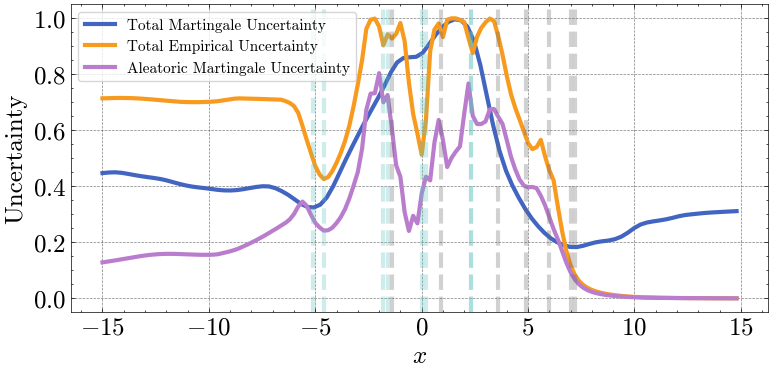

In [44]:
fig, ax = plt.subplots(figsize=(9, 4))

feature_column = 'x1'

x_grid = np.linspace(empirical_results[f'x_x1'].min(), empirical_results[f'x_x1'].max(), 100)
y_total_uncertainty = csaps(empirical_results[f'x_x1'], empirical_results['total_uncertainty'], smooth=0.85)
plt.plot(x_grid, y_total_uncertainty(x_grid), color='C0', linewidth = 3, label='Total Martingale Uncertainty')

sns.lineplot(x=X_array, y=total_uncertainty, ax=ax, label='Total Empirical Uncertainty', color='C4', linewidth=3)
sns.lineplot(x=X_array, y=aleatoric_uncertainty, ax=ax, label='Aleatoric Martingale Uncertainty', color='C5', linewidth=3)
# ax.set_title(rf'Logistic Regression: {feature_interaction.capitalize()} Features')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Uncertainty')

label_0_seen = True
label_1_seen = True
for i, row in D_data.iterrows():
    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y = 0$'
        else:
            label_string = None
        plt.axvline(x=row[feature_column], color='C2', linestyle='--', linewidth=3, alpha=0.3, label=label_string)
    else:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y = 1$'
        else:
            label_string = None
        plt.axvline(x=row[feature_column], color='C3', linestyle='--', linewidth=3, alpha=0.3, label=label_string)

plt.legend(fontsize=11, framealpha=0.8)

# plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)

plt.show()

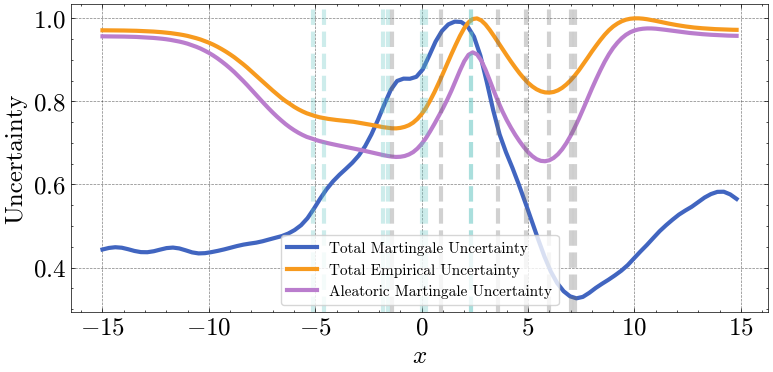

In [331]:
fig, ax = plt.subplots(figsize=(9, 4))

feature_column = 'x1'

x_grid = np.linspace(empirical_results[f'x_x1'].min(), empirical_results[f'x_x1'].max(), 100)
y_total_uncertainty = csaps(empirical_results[f'x_x1'], empirical_results['total_uncertainty'], smooth=0.85)
plt.plot(x_grid, y_total_uncertainty(x_grid), color='C0', linewidth = 3, label='Total Martingale Uncertainty')

sns.lineplot(x=X_array, y=total_uncertainty_kernel, ax=ax, label='Total Empirical Uncertainty', color='C4', linewidth=3)
sns.lineplot(x=X_array, y=aleatoric_uncertainty_kernel, ax=ax, label='Aleatoric Martingale Uncertainty', color='C5', linewidth=3)
# ax.set_title(rf'Logistic Regression: {feature_interaction.capitalize()} Features')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Uncertainty')

label_0_seen = True
label_1_seen = True
for i, row in D_data.iterrows():
    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y = 0$'
        else:
            label_string = None
        plt.axvline(x=row[feature_column], color='C2', linestyle='--', linewidth=3, alpha=0.3, label=label_string)
    else:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y = 1$'
        else:
            label_string = None
        plt.axvline(x=row[feature_column], color='C3', linestyle='--', linewidth=3, alpha=0.3, label=label_string)

plt.legend(fontsize=11, framealpha=0.8)

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_kernel.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)

plt.show()

In [332]:
empirical_total_uncertainty = empirical_results['total_uncertainty'].values
martingale_total_uncertainty = total_uncertainty

L2_norm = np.trapz(np.abs(empirical_total_uncertainty - martingale_total_uncertainty)**2, x=X_array)
print(f"L2 norm: {L2_norm}")

L2 norm: 1.0639459080151148


In [333]:
empirical_total_uncertainty = empirical_results['total_uncertainty'].values
martingale_total_uncertainty_kernel = total_uncertainty_kernel

L2_norm_kernel = np.trapz(np.abs(empirical_total_uncertainty - martingale_total_uncertainty_kernel)**2, x=X_array)
print(f"L2 norm: {L2_norm_kernel}")

L2 norm: 4.731552055507011


### 2D Moons Plots

#### Set Up

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import scipy.integrate as spi

In [12]:
feature_columns = ['x1', 'x2']
feature_ranges = [[-3, 3], [-3, 3]]
feature_increment = 0.01

def get_grid_points(feature_columns, feature_ranges, feature_increment):
    """
    Generate grid points for the given feature columns and ranges.
    
    Args:
        feature_columns (list): List of feature column names.
        feature_ranges (list): List of ranges for each feature column.
        feature_increment (float): Increment for generating grid points.
        
    Returns:
        np.ndarray: Grid points in the form of a 2D array.
    """
    grid_points = []
    for i, col in enumerate(feature_columns):
        grid_points.append(np.arange(feature_ranges[i][0], feature_ranges[i][1] + feature_increment, feature_increment))
    
    return np.array(np.meshgrid(*grid_points)).T.reshape(-1, len(feature_columns))

X = get_grid_points(feature_columns, feature_ranges, feature_increment)

#### Parameters

In [48]:
feature_interaction = "kernel"
model_name = "llama8b"


martingale_results_path = f'martingale_posterior/moons/{model_name}/permutation_sampling_2/{feature_interaction}_logistic.csv'
llm_sample_dir = f'results/martingale_posterior/moons/{model_name}/permutation_sampling_2/llm_samples/'
fig_save_directory = f'figures/martingale_posterior/moons/{model_name}/permutation_sampling_2'


#### Generate Figures - Polynomial Features

In [49]:
if not os.path.exists(fig_save_directory):
    os.makedirs(fig_save_directory)

In [50]:



if feature_interaction == "kernel":
    data_list = []
    for filename in os.listdir(get_src_dir_path(llm_sample_dir)):
        try:
            data_frame = pd.read_csv(os.path.join(get_src_dir_path(llm_sample_dir), filename))
        except:
            continue
        x1 = data_frame['x1'].values
        x2 = data_frame['x2'].values
        x = np.vstack((x1, x2)).T
        label = data_frame['label'].values
        if len(np.unique(label)) != 2:
            continue
        data_list.append((x, label))
        
    total_uncertainty_grid = compute_total_uncertainty_kernel(data_list, X, seed=0, num_samples=100)
    
    aleatoric_uncertainty_grid = compute_aleatoric_uncertainty_kernel(data_list, X, seed=0, num_samples=100)
    
else:
    martingale_results_path = os.path.join(get_src_dir_path('results'), martingale_results_path)
    results_df = pd.read_csv(martingale_results_path)

    b0_list = results_df['b0'].tolist()
    b1_list = results_df['b1'].apply(lambda x: eval(x)).tolist()
    
    total_uncertainty_grid = compute_total_uncertainty(b0_list, b1_list, X, seed=0, num_samples=100, probit_likelihood=False, feature_interaction=feature_interaction)
    
    aleatoric_uncertainty_grid = compute_aleatoric_uncertainty(b0_list, b1_list, X, seed=0, num_samples=100, probit_likelihood=False, feature_interaction=feature_interaction)

In [51]:
import colorsys

def brighter_colour(colour, amount=0.5):
    rgb = mpl.colors.to_rgb(colour)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    # l = min(1, l + amount)
    s = min(1, s + amount)
    new_rgb = colorsys.hls_to_rgb(h, l, s)
    return mpl.colors.to_hex(new_rgb)

In [52]:
dim = int(np.sqrt(total_uncertainty_grid.shape)[0])

In [53]:
D_data_path = os.path.join(get_src_dir_path('results'), f'martingale_posterior/moons/{model_name}/permutation_sampling_2/D_30.csv')
D_data = pd.read_csv(D_data_path)

/tmp/ipykernel_2356715/25771451.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_total.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)


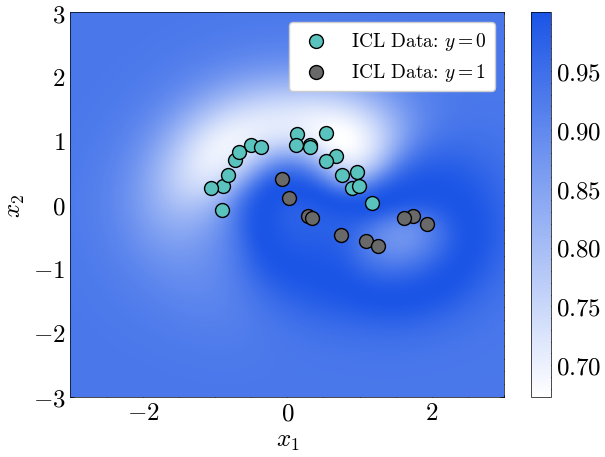

In [54]:
# plot heatmap of total uncertainty grid with grid_points as x and y axes
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_to_C0', ['white', brighter_colour('C0',0.3)])

fig, ax = plt.subplots(figsize=(7, 5))
c = ax.pcolormesh(X[:, 0].reshape(dim, dim), 
                  X[:, 1].reshape(dim, dim),
                  total_uncertainty_grid.reshape(dim, dim),
                  cmap=custom_cmap,
                  shading='auto')
plt.colorbar(c, ax=ax)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')

label_0_seen = False
label_1_seen = False
label_2_seen = False
for i, row in D_data.iterrows():

    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y=0$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C2', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 1:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y=1$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C3', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 2:
        if not label_2_seen:
            label_2_seen = True
            label_string = r'ICL Data: $y=2$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C4', edgecolor='black', s=100, alpha=1, label=label_string)

plt.legend()

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_total.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)

plt.show()

/tmp/ipykernel_2356715/307249265.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_aleatoric.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)


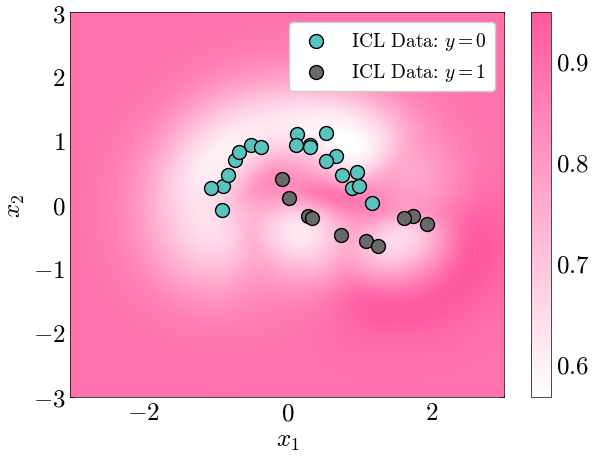

In [55]:
# plot heatmap of total uncertainty grid with grid_points as x and y axes
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_to_C1', ['white', brighter_colour('C1',0.3)])

fig, ax = plt.subplots(figsize=(7, 5))
c = ax.pcolormesh(X[:, 0].reshape(dim, dim), 
                  X[:, 1].reshape(dim, dim),
                  aleatoric_uncertainty_grid.reshape(dim, dim),
                  cmap=custom_cmap,
                  shading='auto')
plt.colorbar(c, ax=ax)
# ax.set_title(r'Cubic Features Aleatoric Uncertainty: Martingale Posterior ($|\mathcal{D}|$ = 15)')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')

label_0_seen = False
label_1_seen = False
label_2_seen = False
for i, row in D_data.iterrows():

    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y=0$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C2', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 1:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y=1$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C3', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 2:
        if not label_2_seen:
            label_2_seen = True
            label_string = r'ICL Data: $y=2$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C4', edgecolor='black', s=100, alpha=1, label=label_string)

plt.legend()

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_aleatoric.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)

plt.show()

/tmp/ipykernel_2356715/2423891247.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_epistemic.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)


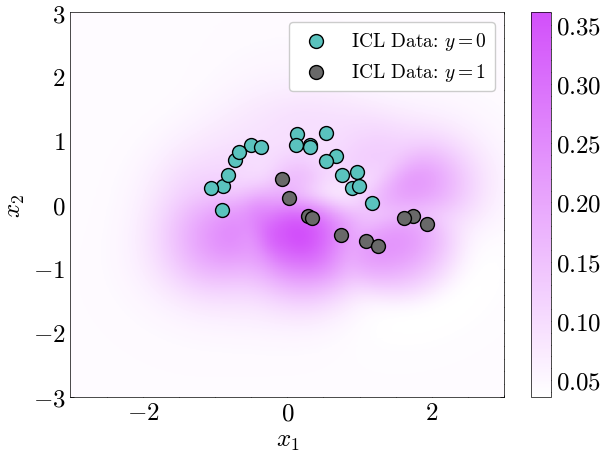

In [56]:
# plot heatmap of total uncertainty grid with grid_points as x and y axes
epistemic_uncertainty_grid = total_uncertainty_grid - aleatoric_uncertainty_grid

custom_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_to_C5', ['white', brighter_colour('C5',0.5)])

fig, ax = plt.subplots(figsize=(7, 5))
c = ax.pcolormesh(X[:, 0].reshape(dim, dim), 
                  X[:, 1].reshape(dim, dim),
                  epistemic_uncertainty_grid.reshape(dim, dim),
                  cmap=custom_cmap,
                  shading='auto')
plt.colorbar(c, ax=ax)
# ax.set_title(r'Cubic Features Aleatoric Uncertainty: Martingale Posterior ($|\mathcal{D}|$ = 15)')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')

label_0_seen = False
label_1_seen = False
label_2_seen = False
for i, row in D_data.iterrows():

    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y=0$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C2', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 1:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y=1$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C3', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 2:
        if not label_2_seen:
            label_2_seen = True
            label_string = r'ICL Data: $y=2$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C4', edgecolor='black', s=100, alpha=1, label=label_string)

plt.legend()

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_epistemic.pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)

plt.show()

In [57]:
empirical_results_directory = f'results/moons/{model_name}/experiment_4/'

empirical_results = get_shots_df(get_src_dir_path(empirical_results_directory), shots=30, num_valid_Va=5, feature_columns=['x1', 'x2'])

In [58]:
martingale_total_uncertainty_df = pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1],
    'total_uncertainty': total_uncertainty_grid,
})

In [59]:
for i, row in empirical_results.iterrows():
    approx_uncertainty = martingale_total_uncertainty_df[(abs(martingale_total_uncertainty_df['x1'] - row['x_x1']) < 0.001) & (abs(martingale_total_uncertainty_df['x2'] - row['x_x2']) < 0.001)]['total_uncertainty'].values[0]
    empirical_results.at[i, 'martingale_uncertainty'] = approx_uncertainty

In [60]:
empirical_results

,x_x1,x_x2,total_uncertainty,martingale_uncertainty
350,-1.5,-1.5,0.95279,0.907989
305,-1.5,-1.3,0.96506,0.900146
284,-1.5,-1.1,0.95979,0.890965
383,-1.5,-0.9,0.98558,0.880147
312,-1.5,-0.7,0.96924,0.866346
...,...,...,...,...
154,2.3,1.5,0.95356,0.929138
22,2.3,1.7,0.96933,0.928238
260,2.3,1.9,0.97439,0.929064
32,2.3,2.1,1.03379,0.929963


In [61]:
empirical_results['squared_error'] = (empirical_results['total_uncertainty'] - empirical_results['martingale_uncertainty'])**2

In [62]:
# Simpsons rule twice to approximate integral on 2D grid

L2_norm_columns = [spi.simpson(empirical_results[empirical_results['x_x1'] == x]['squared_error'], x=empirical_results[empirical_results['x_x1'] == x]['x_x2']) for x in empirical_results['x_x1'].unique()]
L2_norm = spi.simpson(L2_norm_columns, x=empirical_results['x_x1'].unique())

#### L2 Norm

In [64]:
round(L2_norm, 3)

1.254